In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Данные

##### Будем использовать данные соревнования по анализу данных.

##### Одним из способов повышения эффективности взаимодействия банка с клиентами является рассылка предложений о новой услуге не всем клиентам банка, а только определенной части, выбранной исходя из наибольшей склонности реагировать на это предложение.

##### Задача состоит в том, чтобы предложить алгоритм, который будет оценивать склонность клиента к положительному ответу по его характерному описанию. Это можно интерпретировать как вероятность положительного ответа. Предполагается, что, получив такие оценки для определенного набора клиентов, банк будет адресовать предложение только тем клиентам, вероятность которых выше определенного порога.

In [20]:
data = pd.read_csv('data/data_set.csv', sep=None, engine='python')
data.head()

,AGREEMENT_RK,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,EDUCATION,MARITAL_STATUS,...,REG_PHONE_FL,GEN_PHONE_FL,LOAN_NUM_TOTAL,LOAN_NUM_CLOSED,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ,LOAN_AVG_DLQ_AMT,LOAN_MAX_DLQ_AMT,PREVIOUS_CARD_NUM_UTILIZED
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,1,1,1,6,2,1,1580,1580,NaN
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,1,1,1,6,1,1,4020,4020,NaN
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,...,0,1,2,1,11,0,0,0,0,NaN
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,...,1,1,1,1,6,3,1,"1589,92333333333",1590,NaN
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,...,0,1,2,1,16,2,1,"1152,15",2230,NaN


## Предобработка 1

In [21]:
def preproc(df_input : pd.DataFrame):
    drop_cols = ['EDUCATION', 'FACT_ADDRESS_PROVINCE', 'FAMILY_INCOME', 'GEN_INDUSTRY', 
                 'GEN_TITLE', 'JOB_DIR', 'MARITAL_STATUS', 'ORG_TP_FCAPITAL', 'REGION_NM', 
                 'REG_ADDRESS_PROVINCE', 'ORG_TP_STATE', 'POSTAL_ADDRESS_PROVINCE', 'TP_PROVINCE', 
                 'AGREEMENT_RK']

    # Make a copy of data
    df_temp = df_input.copy()

    # Drop the hard columns
    df_temp = df_temp.drop(drop_cols, axis=1)

    digit_cols = ['LOAN_AVG_DLQ_AMT', 'LOAN_MAX_DLQ_AMT', 'CREDIT', 'FST_PAYMENT', 'PERSONAL_INCOME']
    df_temp[digit_cols] = df_temp[digit_cols].replace(regex={',': '.'}).astype('float64')

    return df_temp

In [22]:
data_preproc = preproc(data)
data_preproc.info()

<class 'pandas.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   TARGET                      15223 non-null  int64  
 1   AGE                         15223 non-null  int64  
 2   SOCSTATUS_WORK_FL           15223 non-null  int64  
 3   SOCSTATUS_PENS_FL           15223 non-null  int64  
 4   GENDER                      15223 non-null  int64  
 5   CHILD_TOTAL                 15223 non-null  int64  
 6   DEPENDANTS                  15223 non-null  int64  
 7   PERSONAL_INCOME             15223 non-null  float64
 8   REG_FACT_FL                 15223 non-null  int64  
 9   FACT_POST_FL                15223 non-null  int64  
 10  REG_POST_FL                 15223 non-null  int64  
 11  REG_FACT_POST_FL            15223 non-null  int64  
 12  REG_FACT_POST_TP_FL         15223 non-null  int64  
 13  FL_PRESENCE_FL              15223 non-null

# Train / Test split

In [23]:
from sklearn.model_selection import train_test_split

# label_col = data_preproc.columns == 'TARGET'
# X = data_preproc.loc[:, ~label_col].values
# y = data_preproc.loc[:, label_col].values.flatten()

X = data_preproc.drop(columns=["TARGET"])
y = data_preproc["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Предобработка #2

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_train_prep = pipeline.fit_transform(X_train)
X_test_prep = pipeline.transform(X_test)

## Обучение классификаторов

#### Сравним и обучим три классификатора: KNN, Логистическая регрессия, Дерево решений

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None, 
                            min_samples_split=2, min_samples_leaf=10, class_weight=None)
logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, class_weight=None)
MODELS = [knn, dt, logreg]
for model in MODELS:
    model.fit(X_train_prep, y_train)

/Users/iaroslav/Desktop/ml_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Прогнозы

##### Сделаем прогноз метки классов.

In [26]:
# kNN
y_test_knn = knn.predict(X_test_prep)

# Decision Tree
y_test_dt = dt.predict(X_test_prep)

# Logistic Regression
y_test_logreg = logreg.predict(X_test_prep)

In [27]:
print("Truth  : ", y_test[:10])
print("kNN    : ", y_test_knn[:10])
print("DT     : ", y_test_dt[:10])
print("LogReg : ", y_test_logreg[:10])

Truth  :  6319     0
4252     0
2323     0
6896     1
3299     0
11752    0
8139     0
4983     0
15163    0
14049    0
Name: TARGET, dtype: int64
kNN    :  [0 0 0 0 0 0 0 0 0 0]
DT     :  [0 0 0 0 0 0 0 0 0 0]
LogReg :  [0 0 0 0 0 0 0 0 0 0]


### Метрики качества для прогноза меток

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def quality_metrics_report(y_true, y_pred):
    
    tp = np.sum( (y_true == 1) * (y_pred == 1) )
    fp = np.sum( (y_true == 0) * (y_pred == 1) )
    fn = np.sum( (y_true == 1) * (y_pred == 0) )
    tn = np.sum( (y_true == 0) * (y_pred == 0) )
    
    accuracy = accuracy_score(y_true, y_pred)
    error_rate = 1 - accuracy
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return [tp, fp, fn, tn, accuracy, error_rate, precision, recall, f1]

In [29]:
metrics_report = pd.DataFrame(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Error rate', 'Precision', 'Recall', 'F1'])

metrics_report.loc['kNN', :] = quality_metrics_report(y_test, y_test_knn)
metrics_report.loc['DT', :] = quality_metrics_report(y_test, y_test_dt)
metrics_report.loc['LogReg', :] = quality_metrics_report(y_test, y_test_logreg)

metrics_report

,TP,FP,FN,TN,Accuracy,Error rate,Precision,Recall,F1
kNN,23,70,532,3942,0.868185,0.131815,0.247312,0.041441,0.070988
DT,43,214,512,3798,0.841034,0.158966,0.167315,0.077477,0.105911
LogReg,1,3,554,4009,0.878038,0.121962,0.25,0.001802,0.003578


## ROC AUC

In [ ]:
from sklearn.metrics import roc_curve, auc

probas = [model.predict_proba(X_test_prep)[:, 1] for model in MODELS]

fpr_knn, tpr_knn, _ = roc_curve(y_test, probas[0])
auc_knn = auc(fpr_knn, tpr_knn)

fpr_dt, tpr_dt, _ = roc_curve(y_test, probas[1])
auc_dt = auc(fpr_dt, tpr_dt)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, probas[2])
auc_logreg = auc(fpr_logreg, tpr_logreg)

[array([0.4, 0.2, 0.4, ..., 0. , 0. , 0. ], shape=(4567,)),
 array([0.        , 0.1       , 0.        , ..., 0.36363636, 0.33333333,
        0.1875    ], shape=(4567,)),
 array([0.27965285, 0.09024239, 0.21916527, ..., 0.11488045, 0.13376876,
        0.04637301], shape=(4567,))]

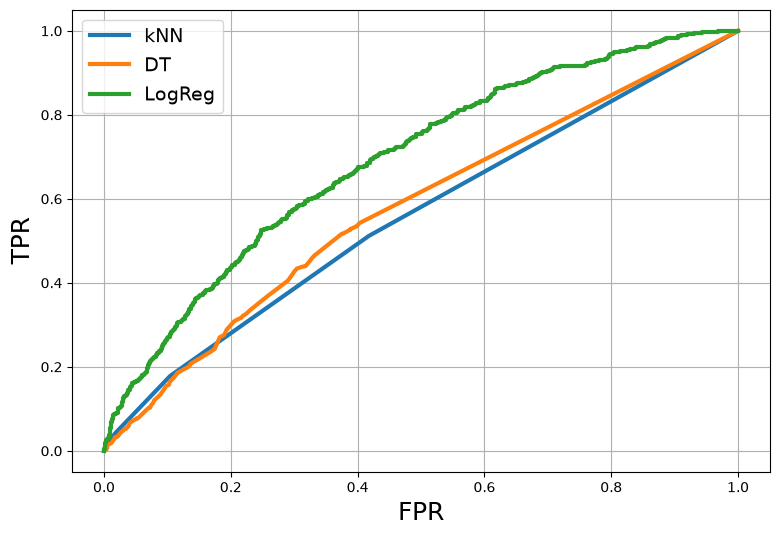

kNN ROC AUC    : 0.5581597549693262
DT ROC AUC     : 0.5761786711936263
LogReg ROC AUC : 0.6912523690190688


In [37]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_knn, tpr_knn, linewidth=3, label='kNN')
plt.plot(fpr_dt, tpr_dt, linewidth=3, label='DT')
plt.plot(fpr_logreg, tpr_logreg, linewidth=3, label='LogReg')

plt.xlabel('FPR', size=18)
plt.ylabel('TPR', size=18)

plt.legend(loc='best', fontsize=14)
plt.grid()
plt.show()

print('kNN ROC AUC    :', auc_knn)
print('DT ROC AUC     :', auc_dt)
print('LogReg ROC AUC :', auc_logreg)

## Precision-Recall curve

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_knn, recall_knn, _ = precision_recall_curve(y_test, probas[0])
ap_knn = average_precision_score(y_test, probas[0])

precision_dt, recall_dt, _ = precision_recall_curve(y_test, probas[1])
ap_dt = average_precision_score(y_test, probas[1])
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, probas[2])
ap_logreg = average_precision_score(y_test, probas[2])

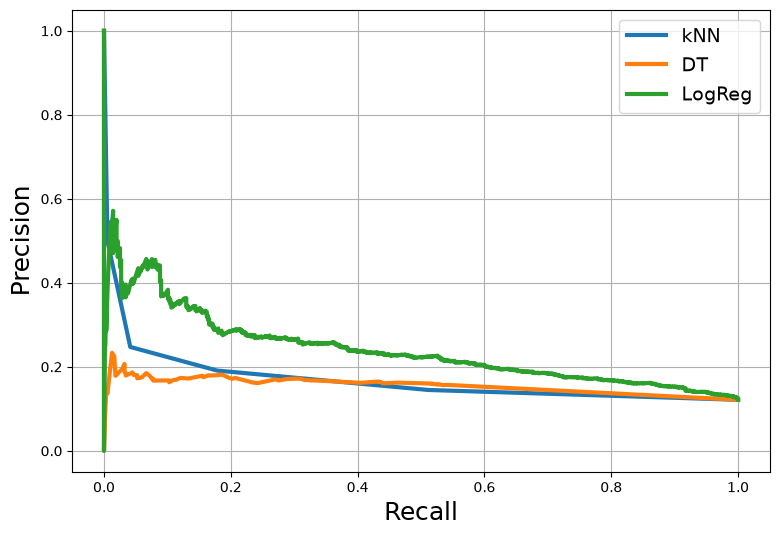

kNN AP    : 0.14542423986420286
DT AP     : 0.14765517012880244
LogReg AP : 0.23990750261891974


In [39]:
plt.figure(figsize=(9, 6))
plt.plot(recall_knn, precision_knn, linewidth=3, label='kNN')
plt.plot(recall_dt, precision_dt, linewidth=3, label='DT')
plt.plot(recall_logreg, precision_logreg, linewidth=3, label='LogReg')

plt.xlabel('Recall', size=18)
plt.ylabel('Precision', size=18)

plt.legend(loc='best', fontsize=14)
plt.grid()
plt.show()

print('kNN AP    :', ap_knn)
print('DT AP     :', ap_dt)
print('LogReg AP :', ap_logreg)